# Step 2 Nora 
Optimization of SVM and Logistic Regression models + Voting Classifier 

In [1]:
import numpy as np
import time
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Loading the features generated in Step 1
X_train = np.load(r'C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\data\X_train_mfcc.npy')
y_train = np.load(r'C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\data\y_train.npy')
X_dev   = np.load(r'C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\data\X_dev_mfcc.npy')
y_dev   = np.load(r'C:\Users\norab\Documents\Cours_ESILV_A4\Machine Learning\deepfake-audio-project\data\y_dev.npy')

X_train.shape, X_dev.shape


((500, 26), (200, 26))

In [2]:
# Construction of the SVM pipeline
pipeline_svm = make_pipeline(
    StandardScaler(),
    SVC(probability=True, class_weight='balanced', random_state=42)
)
# Definition of the hyperparameter grid
param_grid_svm = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["rbf", "linear"],
    "svc__gamma": ["scale", "auto"]
}
# GridSearchCV
grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=param_grid_svm,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1 
)
# Model training
t0 = time.time()
grid_svm.fit(X_train, y_train)
svm_train_time = time.time() - t0

print("Best params SVM :", grid_svm.best_params_)
print("Best CV AUC SVM :", grid_svm.best_score_)
print("Training time :", svm_train_time, "seconds")


Best params SVM : {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV AUC SVM : 0.9600749361554776
Training time : 4.142802476882935 seconds


In [3]:
# Construction of a pipeline for Logistic Regression
pipeline_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
)

param_grid_lr = {
    "logisticregression__C": [0.1, 1, 10],
}

grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

t0 = time.time()
grid_lr.fit(X_train, y_train)
lr_train_time = time.time() - t0

print("Best params LR :", grid_lr.best_params_)
print("Best params LR :", grid_lr.best_params_)
print("Best CV AUC LR :", grid_lr.best_score_)
print("Training time :", lr_train_time, "seconds")


Best params LR : {'logisticregression__C': 1}
Best params LR : {'logisticregression__C': 1}
Best CV AUC LR : 0.8872169198805349
Training time : 0.12390589714050293 seconds


In [4]:
# Building a Voting Classifier
voting = VotingClassifier(
    estimators=[
        ('svm', grid_svm.best_estimator_),
        ('lr',  grid_lr.best_estimator_)
    ],
    voting='soft'
)

t0 = time.time()
voting.fit(X_train, y_train)
voting_train_time = time.time() - t0

print("Voting classifier trained in", voting_train_time, "seconds")


Voting classifier trained in 0.049533843994140625 seconds


In [5]:
# Evaluation function
def evaluate(name, model, X, y):
    t0 = time.time()
    y_proba = model.predict_proba(X)[:, 1]
    inference_time = time.time() - t0

    y_pred = (y_proba >= 0.5).astype(int)
    
    print(f"===== {name} =====")
    print("Accuracy :", accuracy_score(y, y_pred))
    print("F1-score :", f1_score(y, y_pred))
    print("ROC-AUC  :", roc_auc_score(y, y_proba))
    print("Inference time :", inference_time, "seconds")
    print("Confusion matrix:\n", confusion_matrix(y, y_pred))
    print()

evaluate("SVM (best)", grid_svm.best_estimator_, X_dev, y_dev)
evaluate("Logistic Regression (best)", grid_lr.best_estimator_, X_dev, y_dev)
evaluate("VotingClassifier (SVM + LR)", voting, X_dev, y_dev)

===== SVM (best) =====
Accuracy : 0.93
F1-score : 0.9627659574468085
ROC-AUC  : 0.9093070652173912
Inference time : 0.0060613155364990234 seconds
Confusion matrix:
 [[  5  11]
 [  3 181]]

===== Logistic Regression (best) =====
Accuracy : 0.855
F1-score : 0.9164265129682997
ROC-AUC  : 0.9320652173913043
Inference time : 0.0011456012725830078 seconds
Confusion matrix:
 [[ 12   4]
 [ 25 159]]

===== VotingClassifier (SVM + LR) =====
Accuracy : 0.925
F1-score : 0.9591280653950953
ROC-AUC  : 0.9432744565217391
Inference time : 0.005584716796875 seconds
Confusion matrix:
 [[  9   7]
 [  8 176]]



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay


<Figure size 800x600 with 0 Axes>

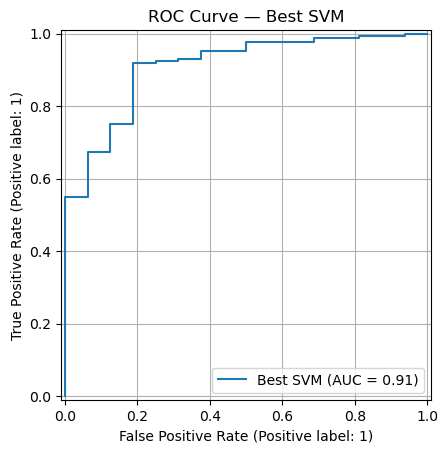

<Figure size 800x600 with 0 Axes>

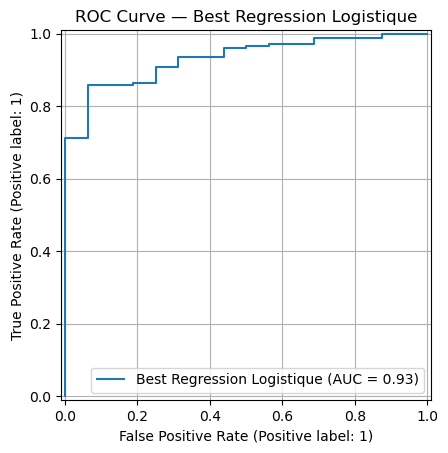

<Figure size 800x600 with 0 Axes>

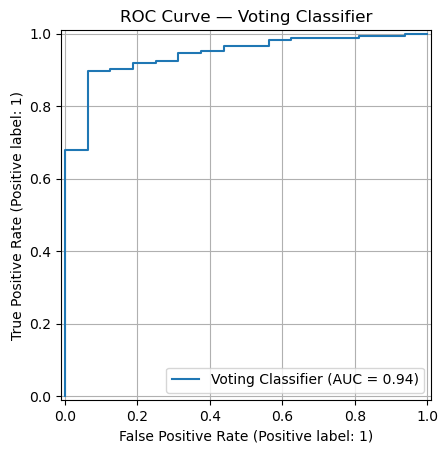

In [8]:
# ROC curves

models = {
    "Best SVM": grid_svm.best_estimator_,
    "Best Regression Logistique": grid_lr.best_estimator_,
    "Voting Classifier": voting
}

for name, model in models.items():
    plt.figure(figsize=(8, 6))
    RocCurveDisplay.from_estimator(model, X_dev, y_dev, name=name)
    plt.title(f"ROC Curve — {name}")
    plt.grid(True)
    plt.show()



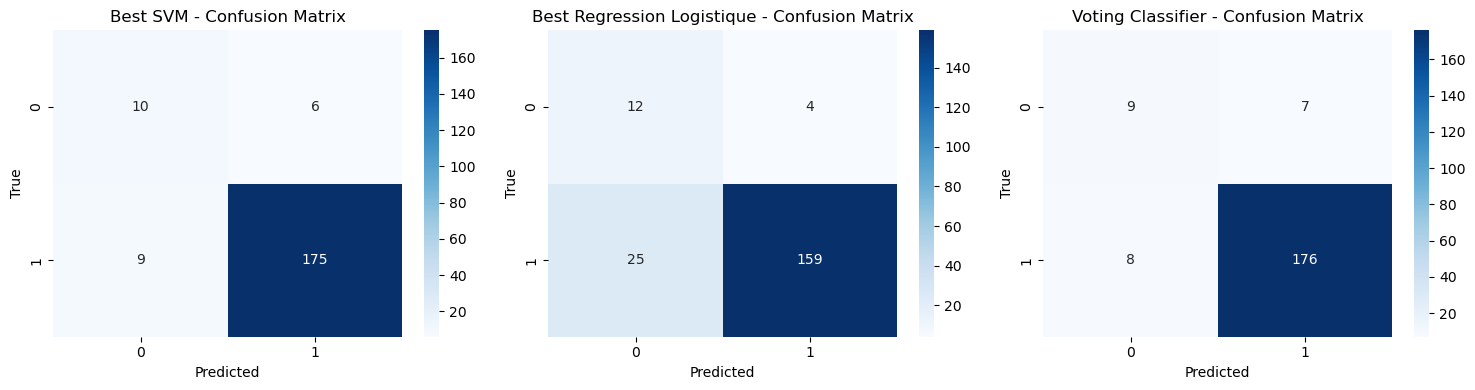

In [9]:
# Heatmaps of confusion matrix

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    y_pred = model.predict(X_dev)
    cm = confusion_matrix(y_dev, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

plt.tight_layout()
plt.show()


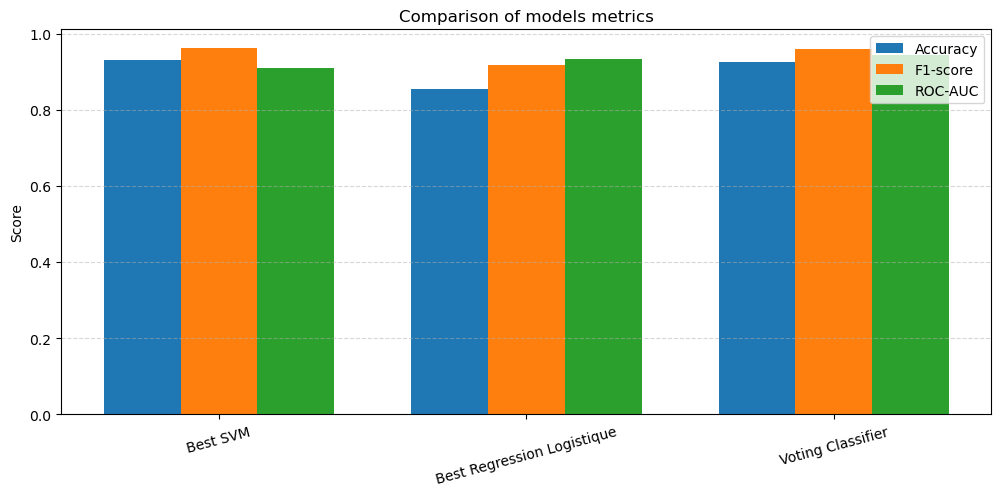

In [10]:
# Comparative performance bar plots
import numpy as np

accuracies = []
f1_scores = []
aucs = []

for name, model in models.items():
    y_proba = model.predict_proba(X_dev)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    accuracies.append(accuracy_score(y_dev, y_pred))
    f1_scores.append(f1_score(y_dev, y_pred))
    aucs.append(roc_auc_score(y_dev, y_proba))

labels = list(models.keys())
x = np.arange(len(labels))

plt.figure(figsize=(12, 5))
plt.bar(x - 0.25, accuracies, width=0.25, label="Accuracy")
plt.bar(x,         f1_scores,   width=0.25, label="F1-score")
plt.bar(x + 0.25, aucs,         width=0.25, label="ROC-AUC")

plt.xticks(x, labels, rotation=15)
plt.ylabel("Score")
plt.title("Comparison of models metrics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


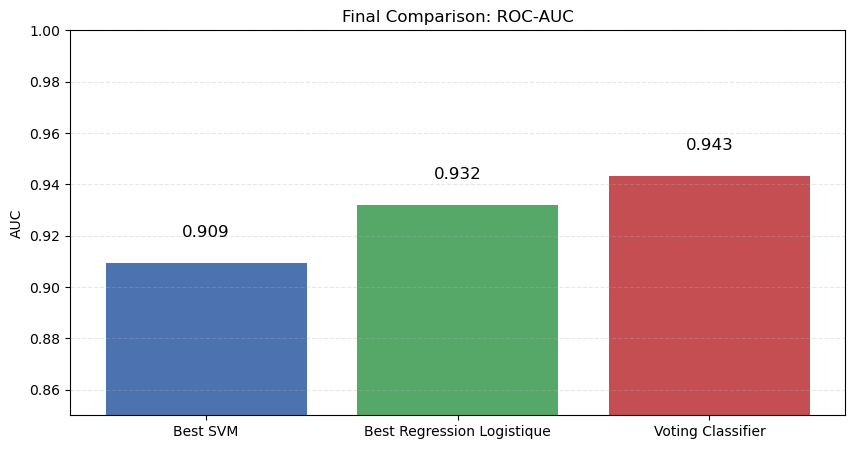

In [11]:
# Comparison of the models

plt.figure(figsize=(10, 5))

metric = aucs
plt.bar(labels, metric, color=["#4c72b0", "#55a868", "#c44e52"])

plt.title("Final Comparison: ROC-AUC")
plt.ylabel("AUC")
plt.ylim(0.85, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(metric):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=12)

plt.show()
